Based on bad_fibers-everest.ipynb

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
# cat = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/everest/main_done_cumulative_lrg.fits'))
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/everest/main_done_cumulative_lrg.fits'))
print(len(cat))

cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

344684


In [4]:
cat['MEAN_X'], cat['MEAN_Y'] = 0., 0.
for fiber in np.unique(cat['FIBER']):
    mask = cat['FIBER']==fiber
    cat['MEAN_X'][mask] = np.mean(cat['FIBERASSIGN_X'][mask])
    cat['MEAN_Y'][mask] = np.mean(cat['FIBERASSIGN_Y'][mask])

In [5]:
# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
min_depth = 800.
mask = cat['EFFTIME_LRG']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # # ZDONE fibers
# # mask = cat['ZDONE']==1
# # print('ZDONE   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))

FIBERSTATUS    5098 339586 0.014790358705364914
No data    0 339586 0.0
Min depth    7570 332016 0.022291849487316908


In [6]:
# # WISE and MEDIUM masks
# maskbits = [8, 9, 11]
# mask_clean = np.ones(len(cat), dtype=bool)
# for bit in maskbits:
#     mask_clean &= (cat['MASKBITS'] & 2**bit)==0
# print('MASKBITS', np.sum(mask_clean), np.sum(~mask_clean), np.sum(mask_clean)/len(mask_clean))
# cat = cat[mask_clean]

In [7]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cat['gmag'] = 22.5 - 2.5*np.log10(cat['FLUX_G']) - 3.214 * cat['EBV']
    cat['rmag'] = 22.5 - 2.5*np.log10(cat['FLUX_R']) - 2.165 * cat['EBV']
    cat['zmag'] = 22.5 - 2.5*np.log10(cat['FLUX_Z']) - 1.211 * cat['EBV']
    cat['w1mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W1']) - 0.184 * cat['EBV']
    cat['w2mag'] = 22.5 - 2.5*np.log10(cat['FLUX_W2']) - 0.113 * cat['EBV']
    cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']

In [8]:
mask_gal = cat['SPECTYPE']=='GALAXY'
mask_star = (cat['SPECTYPE']=='STAR') | (cat['Z']<0.0003)
mask_qso = cat['SPECTYPE']=='QSO'

# Force the very low-z objects to have SPECTYPE=STAR
cat['SPECTYPE'][mask_star] = 'STAR'

In [9]:
cat['Z'][mask_gal].max()

1.699740294373923

In [10]:
mask_quality0 = cat['ZWARN']==0
mask_quality0 &= cat['DELTACHI2']>15
mask_quality0 &= cat['Z']<1.4
print(np.sum(~mask_quality0)/len(mask_quality0))

# Custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<10)
mask_quality = cat['ZWARN']==0
mask_quality &= cat['Z']<1.4
mask_quality &= (~mask_remove)
print(np.sum(~mask_quality)/len(mask_quality))

# Custom cut with DELTACHI2>15
d = (10**(3 - 3.5*cat['Z']))
mask_remove = (d>30) & (cat['DELTACHI2']<30)
mask_remove |= (d<30) & (cat['DELTACHI2']<d)
mask_remove |= (cat['DELTACHI2']<15)
mask_quality1 = cat['ZWARN']==0
mask_quality1 &= cat['Z']<1.4
mask_quality1 &= (~mask_remove)
print(np.sum(~mask_quality1)/len(mask_quality1))

# cat = cat[mask_quality]
# print(len(cat))

0.026004770854416655
0.023992819623150693
0.0278570912245193


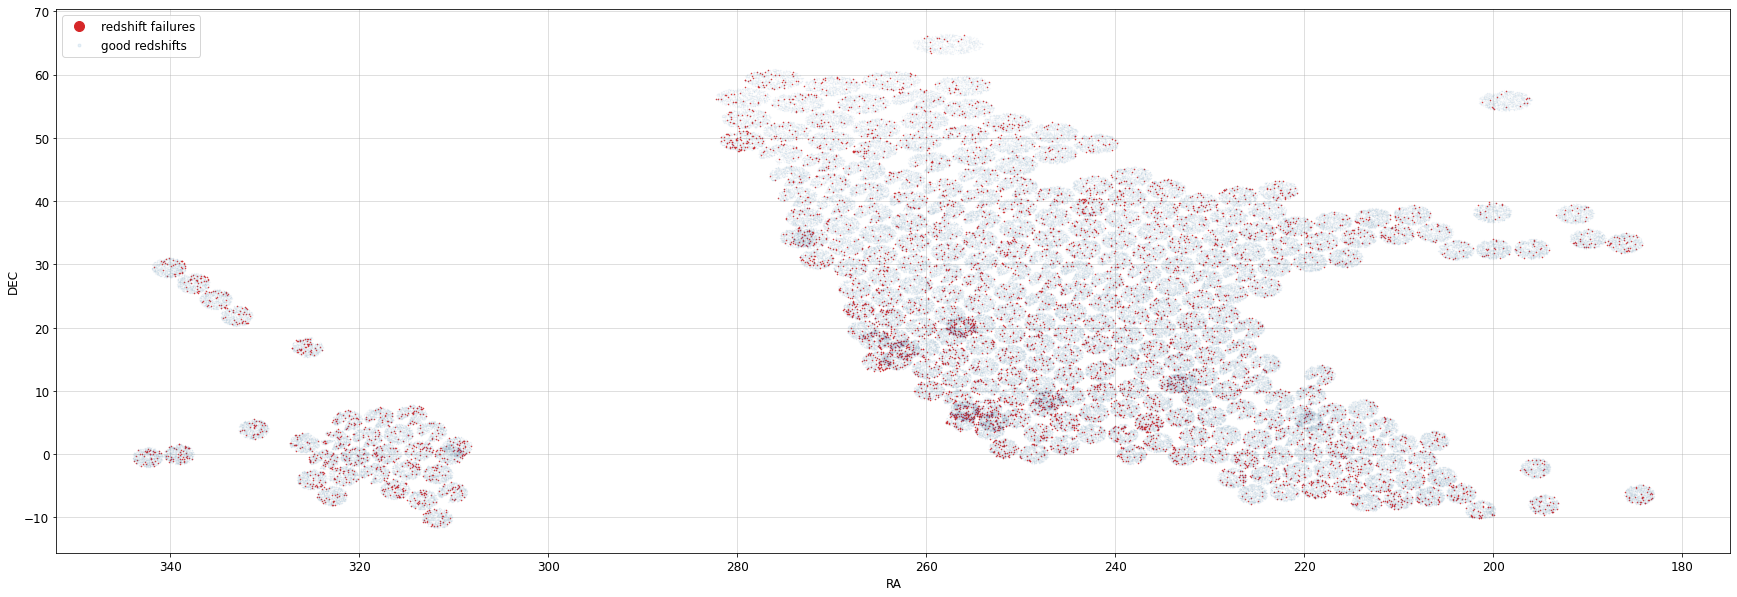

In [11]:
plt.figure(figsize=(30, 10))
plt.plot(cat['TARGET_RA'][~mask_quality], cat['TARGET_DEC'][~mask_quality], 'C3.', ms=1, label='redshift failures')
plt.plot(cat['TARGET_RA'][mask_quality], cat['TARGET_DEC'][mask_quality], 'C0.', ms=.3, alpha=0.1, label='good redshifts')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper left', markerscale=20)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

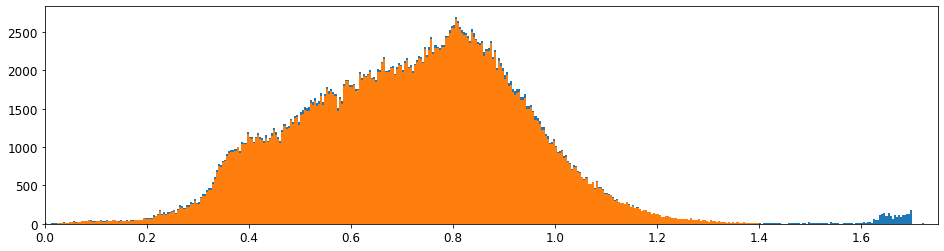

In [12]:
plt.figure(figsize=(16, 4))
plt.hist(cat['Z'][(~mask_star)], 500, log=False, range=(0, 2.))
plt.hist(cat['Z'][(~mask_star) & mask_quality1], 500, log=False, range=(0, 2.))
plt.xlim(0, 1.75)
plt.show()

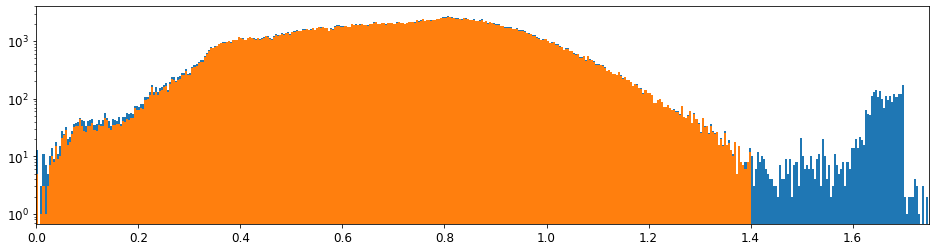

In [13]:
plt.figure(figsize=(16, 4))
plt.hist(cat['Z'][(~mask_star)], 500, log=True, range=(0, 2.))
plt.hist(cat['Z'][(~mask_star) & mask_quality1], 500, log=True, range=(0, 2.))
plt.xlim(0, 1.75)
plt.show()

In [14]:
fiberstats = Table()
fiberstats['FIBER'], fiberstats['n_tot'] = np.unique(cat['FIBER'], return_counts=True)
fiberstats.sort('n_tot')

tt = Table()
tt['FIBER'], tt['n_fail'] = np.unique(cat['FIBER'][~mask_quality], return_counts=True)
fiberstats = join(fiberstats, tt, keys='FIBER', join_type='outer').filled(0)
fiberstats['frac_fail'] = fiberstats['n_fail']/fiberstats['n_tot']

error_floor = True

n, p = fiberstats['n_tot'].copy(), fiberstats['frac_fail'].copy()
if error_floor:
    p1 = np.maximum(p, 1/n)  # error floor
else:
    p1 = p
fiberstats['frac_fail_err'] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
fiberstats.sort('n_fail')

fiberstats

FIBER,n_tot,n_fail,frac_fail,frac_fail_err
int32,int64,int64,float64,float64
1889,78,0,0.0,0.012738064937539489
2627,88,0,0.0,0.011298885771811653
4683,55,0,0.0,0.01801577070206772
4686,51,0,0.0,0.019414657705424988
1071,97,0,0.0,0.01025600006956303
2629,69,0,0.0,0.014387350379788876
4283,78,0,0.0,0.012738064937539489
2625,77,0,0.0,0.012902406138576674
2633,84,0,0.0,0.011833688064142915


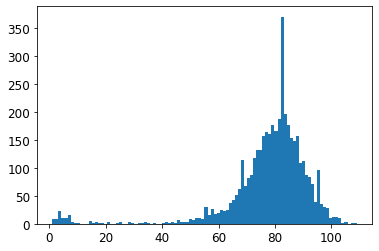

In [15]:
plt.hist(fiberstats['n_tot'], 100);

In [16]:
fiberstats['MEAN_X'], fiberstats['MEAN_Y'] = 0., 0.
for index, fiber in enumerate(fiberstats['FIBER']):
    mask = cat['FIBER']==fiber
    fiberstats['MEAN_X'][index], fiberstats['MEAN_Y'][index] = cat['MEAN_X'][mask][0], cat['MEAN_Y'][mask][0]

In [17]:
print(len(fiberstats))
mask = fiberstats['n_tot']>40
print(np.sum(mask))

4253
4135


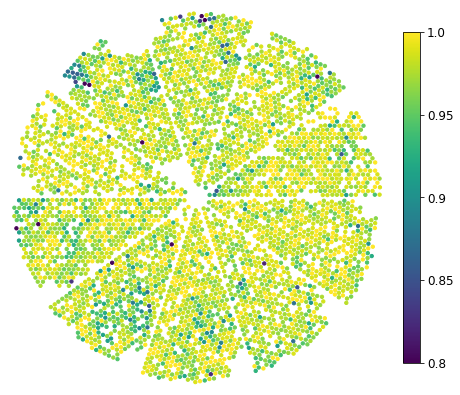

In [18]:
mask = fiberstats['n_tot']>40

fig, ax = plt.subplots(figsize=(6.5, 5.6))
cax = ax.scatter(fiberstats['MEAN_X'][mask], fiberstats['MEAN_Y'][mask], c=1-fiberstats['frac_fail'][mask],
            s=11, vmin=0.8, vmax=1., cmap='viridis')
ax.axis([-420, 420, -420, 420])
# plt.colorbar(fraction=0.04, pad=0.04)
cbar = fig.colorbar(cax, ticks=[0.80, 0.85, 0.90, 0.95, 1.0], fraction=0.04, pad=0.04)
cbar.ax.set_yticklabels([0.80, 0.85, 0.90, 0.95, 1.0])  # horizontal colorbar
plt.axis('off')
plt.tight_layout()
plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/fiber_to_fiber.pdf')
plt.show()

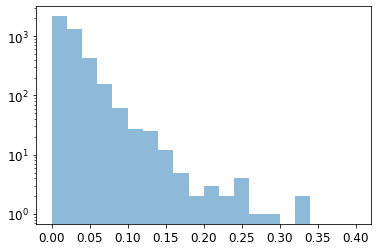

In [19]:
plt.hist(fiberstats['frac_fail'], 20, range=(0, 0.4), log=True, alpha=0.5)
plt.show()

In [20]:
median_efftime = Table()
median_efftime['FIBER'] = np.unique(cat['FIBER'])
median_efftime['EFFTIME_LRG'] = np.nan
for index in range(len(median_efftime)):
    fiber = median_efftime['FIBER'][index]
    mask = cat['FIBER']==fiber
    median_efftime['EFFTIME_LRG'][index] = np.median(cat['EFFTIME_LRG'][mask])

fiberstats = join(fiberstats, median_efftime, keys='FIBER')

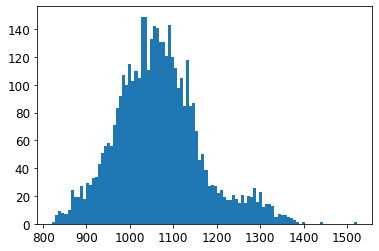

In [21]:
plt.hist(fiberstats['EFFTIME_LRG'], 100);

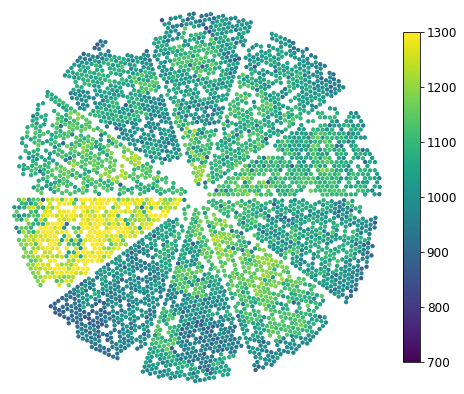

In [22]:
mask = fiberstats['n_tot']>40

fig, ax = plt.subplots(figsize=(6.55, 5.6))
cax = ax.scatter(fiberstats['MEAN_X'][mask], fiberstats['MEAN_Y'][mask], c=fiberstats['EFFTIME_LRG'][mask],
            s=11, vmin=700, vmax=1300, cmap='viridis')
ax.axis([-420, 420, -420, 420])
fig.colorbar(cax, fraction=0.04, pad=0.04)
plt.axis('off')
plt.tight_layout()
# plt.savefig('/Users/rongpu/git/desi-targets/lrg_paper/figures/fiber_to_fiber.pdf')
plt.show()